In [1]:
import mne 

In [2]:
# plot outside of the notebook

In [3]:
# read .edf data
raw_3 = mne.io.read_raw_edf('files/S001/S001R03.edf', preload=True)
raw_3.info
# get duration of the recording
duration = raw_3.n_times / raw_3.info['sfreq']
print(f"Duration of the recording: {duration:.2f} seconds")

Extracting EDF parameters from files/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Duration of the recording: 125.00 seconds


Using matplotlib as 2D backend.


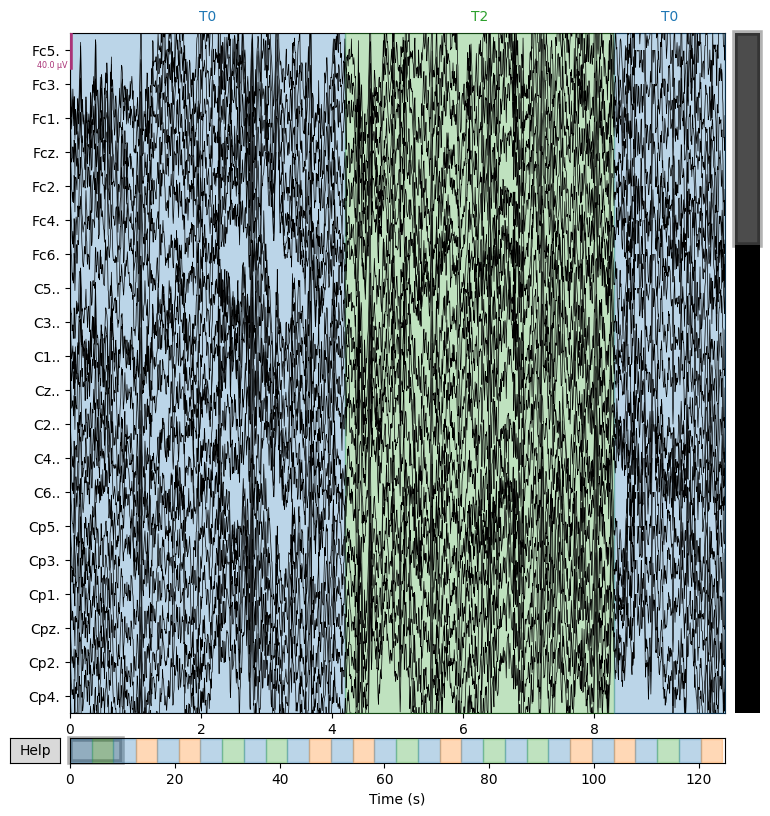

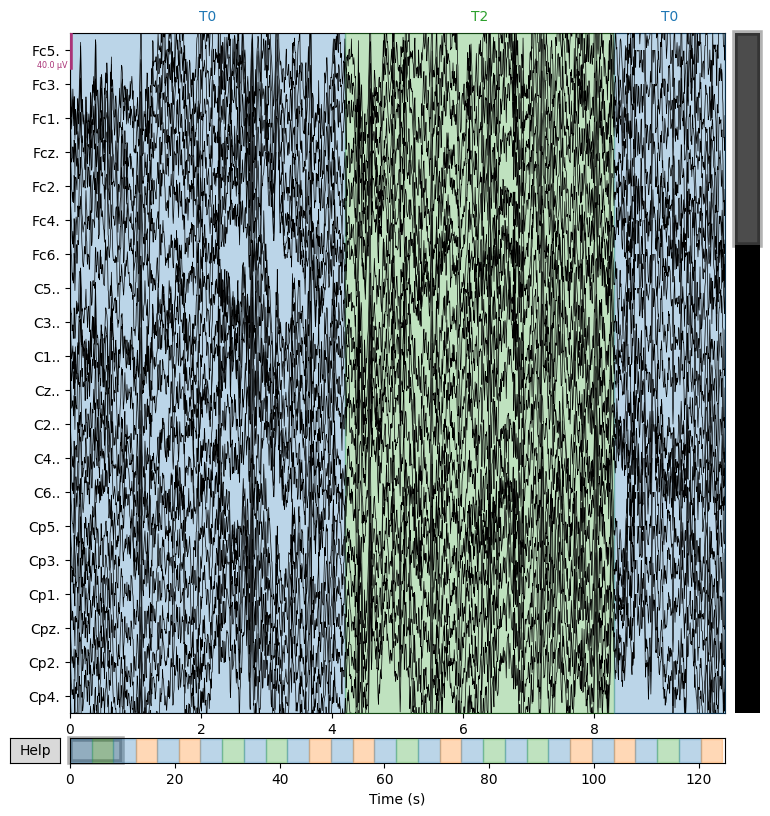

In [4]:

# plot 
raw_3.plot()

In [5]:
# get annotations
annotations = raw_3.annotations
print(annotations)

print(annotations.description)
print(annotations.onset)
print(annotations.duration)

df_annotations = annotations.to_data_frame()
print(df_annotations)


<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
['T0' 'T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2' 'T0' 'T2' 'T0' 'T1' 'T0' 'T1'
 'T0' 'T2' 'T0' 'T1' 'T0' 'T2' 'T0' 'T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2'
 'T0' 'T1']
[  0.    4.2   8.3  12.5  16.6  20.8  24.9  29.1  33.2  37.4  41.5  45.7
  49.8  54.   58.1  62.3  66.4  70.6  74.7  78.9  83.   87.2  91.3  95.5
  99.6 103.8 107.9 112.1 116.2 120.4]
[4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1
 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1]
                     onset  duration description
0  2009-08-12 16:15:00.000       4.2          T0
1  2009-08-12 16:15:04.200       4.1          T2
2  2009-08-12 16:15:08.300       4.2          T0
3  2009-08-12 16:15:12.500       4.1          T1
4  2009-08-12 16:15:16.600       4.2          T0
5  2009-08-12 16:15:20.800       4.1          T1
6  2009-08-12 16:15:24.900       4.2          T0
7  2009-08-12 16:15:29.100       4.1          T2
8  2009-08-12 16:15:33.200       4.2         

Extracting EDF parameters from files/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from files/S001/S001R05.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


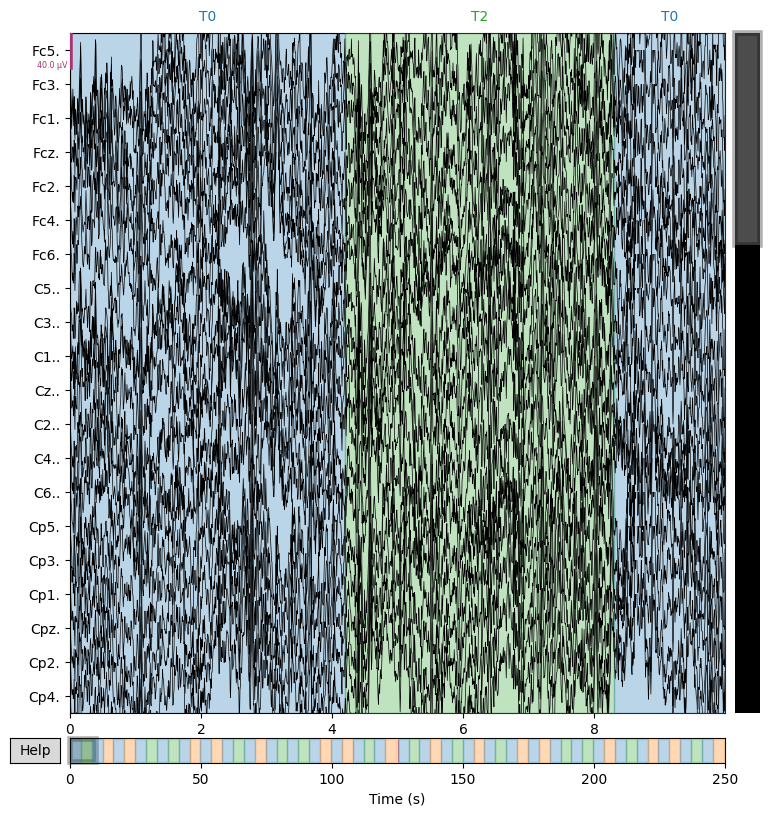

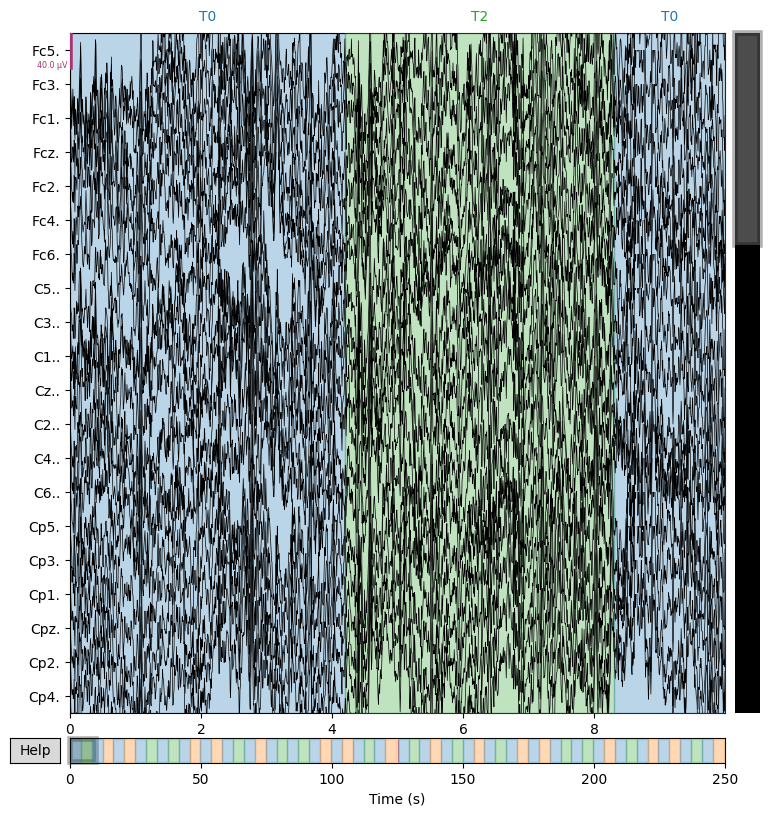

In [6]:
""" concatenate runs 3 and. 5 and filter 8-30Hz and set average reference and z-score the data"""
from mne.io import read_raw_edf, concatenate_raws

# 1. LOAD AND CONCATENATE
data_path = 'files/S001/'

# raw_fnames = [data_path + f for f in ['S001R03.edf', 'S001R05.edf']]
# raw = concatenate_raws([read_raw_edf(f, preload=True) for f in raw_fnames])

""" cut both runs to 1 minute to have smaller data """
raw1 = read_raw_edf(data_path + 'S001R03.edf', preload=True)
raw2 = read_raw_edf(data_path + 'S001R05.edf', preload=True)

raw = concatenate_raws([raw1, raw2])

# raw.filter(0.1, 79., fir_design='firwin', skip_by_annotation='edge', phase='zero')
# raw.set_eeg_reference('average', projection=False)

## z-score the data
data = raw.get_data()
data_zscored = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)


# raw._data = data_zscored

# save data_zscored to npy file
import numpy as np
np.save('S001R03_concat_S001R05_zscored.npy', data_zscored.T)

#plot from start to duration 
raw.plot()


In [7]:
# Load the z-scored data
data_zscored = np.load('S001R03_concat_S001R05_zscored.npy')
# data_zscored = np.load('../data/eeg/EEG_data_zscored.npy')

print(data_zscored.shape)

(40000, 64)


In [8]:
from scipy.signal.windows import hann
from scipy.signal import filtfilt
import numpy as np

window_length = 15
hann_window = hann(window_length)

data_smoothed = filtfilt(hann_window, 1, data_zscored, axis=0)

np.save('S001R03_concat_S001R05_smoothed.npy', data_smoothed)

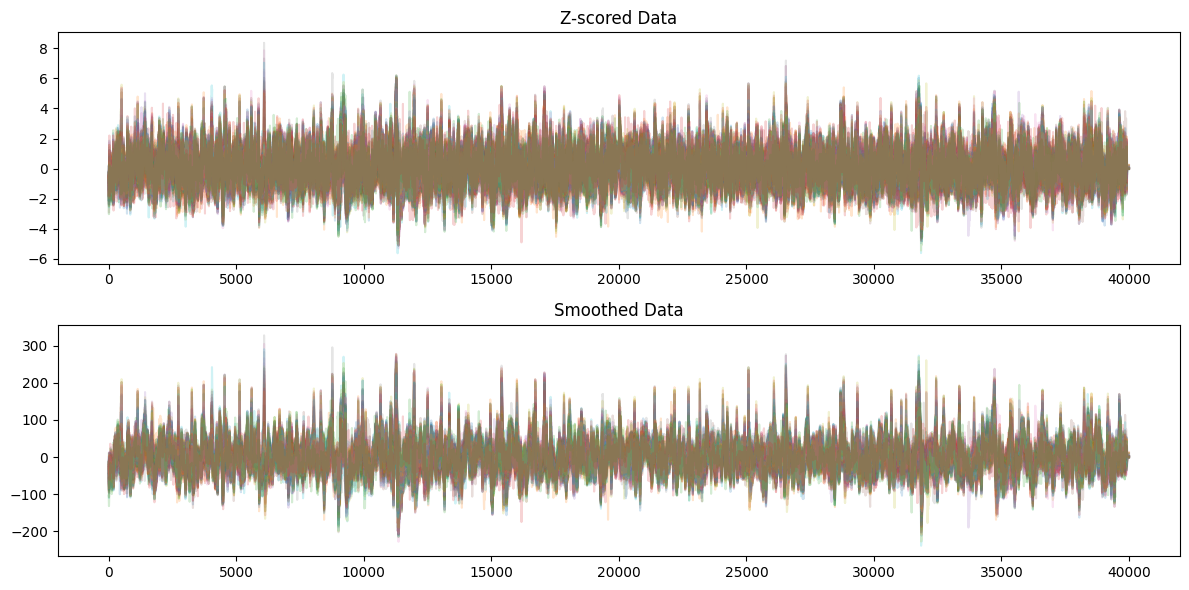

In [9]:
# plot z-scored data and smoothed data 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(data_zscored, label='Z-scored Data' , alpha=0.2)
plt.title('Z-scored Data')
plt.subplot(2, 1, 2)
plt.plot(data_smoothed, label='Smoothed Data' , alpha=0.2)
plt.title('Smoothed Data')
plt.tight_layout()
plt.show()